# Synthetic baseline check

Purpose: verify the full stability pipeline without TabPFN-Wide.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from stablewide.notebook_utils import find_project_root, run_experiment, read_outputs, core_subsample_table
ROOT = find_project_root(ROOT)
print(ROOT)

C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL


In [2]:
OUT = ROOT / "outputs" / "01_baseline_smoke"
args = [
    "--synthetic", "--quick",
    "--methods", "anova,rf,l1,l2",
    "--out", str(OUT),
]
run_experiment(ROOT, args)

C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL\.venv\Scripts\python.exe C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL\run_experiment.py --synthetic --quick --methods anova,rf,l1,l2 --out C:\Users\scoti\PycharmProjects\STABLE_WIDE_FINAL\outputs\01_baseline_smoke


CompletedProcess(args=['C:\\Users\\scoti\\PycharmProjects\\STABLE_WIDE_FINAL\\.venv\\Scripts\\python.exe', 'C:\\Users\\scoti\\PycharmProjects\\STABLE_WIDE_FINAL\\run_experiment.py', '--synthetic', '--quick', '--methods', 'anova,rf,l1,l2', '--out', 'C:\\Users\\scoti\\PycharmProjects\\STABLE_WIDE_FINAL\\outputs\\01_baseline_smoke'], returncode=0)

In [3]:
res = read_outputs(OUT)
print(res.get("decision", "No decision file"))

=== Pre-registered pilot decision (v4) ===
decision k=10; AUROC floor=0.75; 
gene-stability ceiling=0.50; pairwise margin=0.10
minimum outer splits with finite estimates=3
Insufficient outer-split evidence for a decision; do not interpret as a null result.

INCONCLUSIVE


In [4]:
table = core_subsample_table(res["aggregate_results.csv"], k=10)
table.round(3)

,method,n_train,auroc_mean_mean,auroc_mean_ci_low,auroc_mean_ci_high,jaccard_gene_mean,jaccard_gene_ci_low,jaccard_gene_ci_high,jaccard_module_mean,jaccard_module_ci_low,jaccard_module_ci_high
5,anova,100,NaN,NaN,NaN,0.552,0.474,0.629,0.912,0.825,1.000
13,l1,100,0.860,0.834,0.886,0.265,0.263,0.267,0.474,0.471,0.478
21,l2,100,0.658,0.624,0.693,0.238,0.181,0.296,0.310,0.282,0.339
33,rf,100,0.793,0.752,0.834,0.456,0.366,0.546,0.782,0.643,0.920
1,anova,50,NaN,NaN,NaN,0.195,0.112,0.279,0.336,0.222,0.450
9,l1,50,0.745,0.690,0.800,NaN,NaN,NaN,NaN,NaN,NaN
17,l2,50,0.638,0.618,0.657,0.099,0.065,0.132,0.177,0.159,0.195
29,rf,50,0.675,0.639,0.712,0.071,0.021,0.122,0.143,0.075,0.211


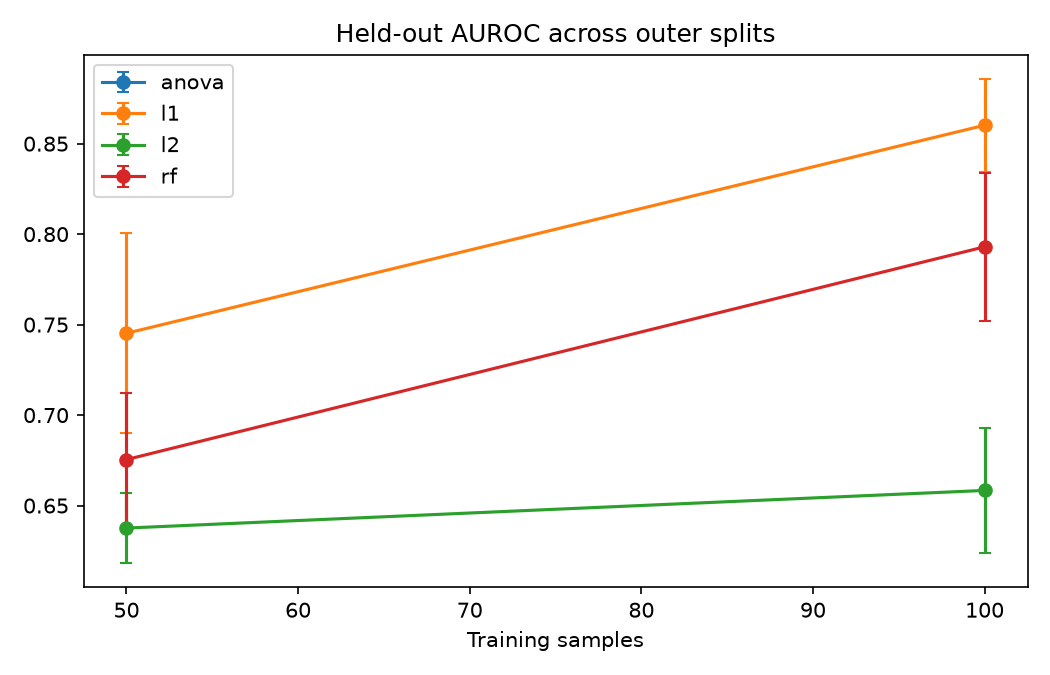

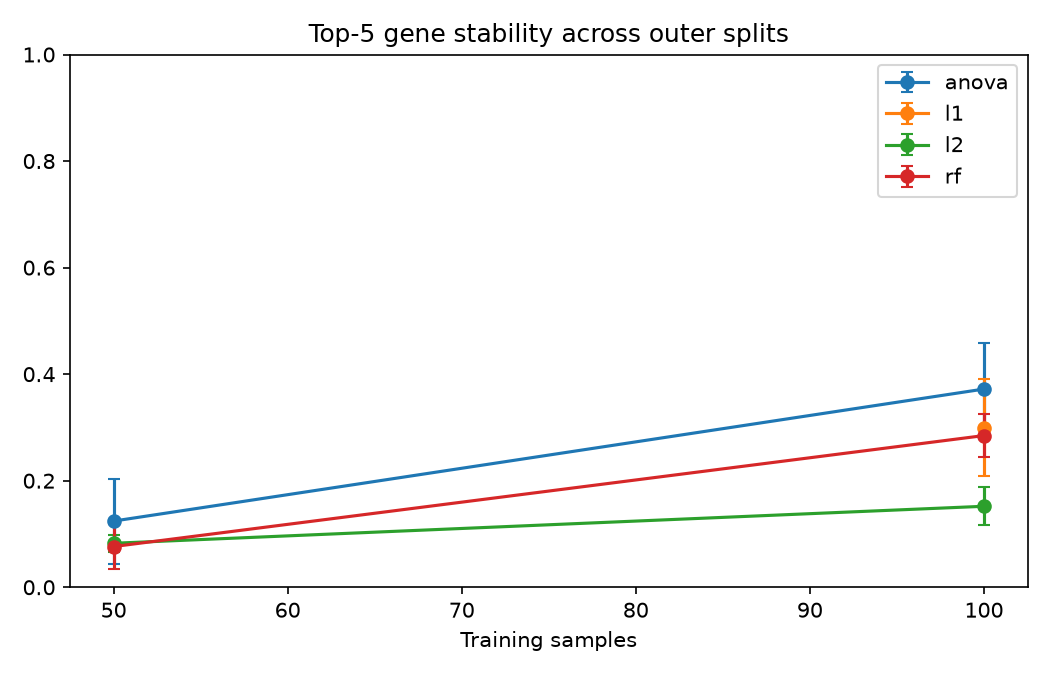

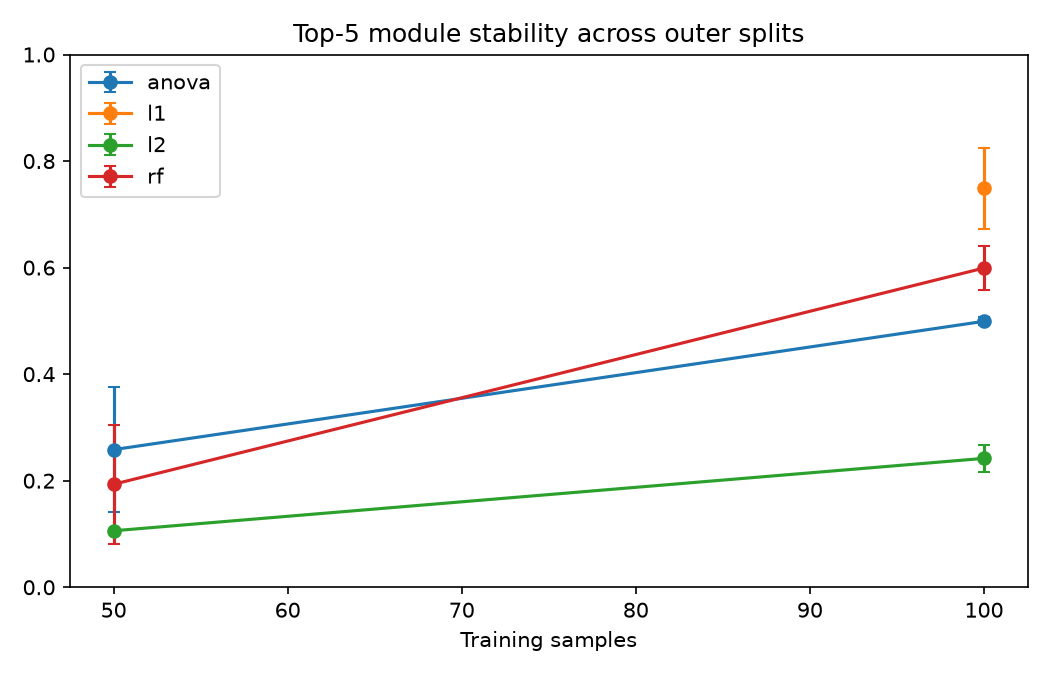

In [5]:
from IPython.display import Image, display
for f in ["aggregate_auroc.png", "aggregate_gene_stability.png", "aggregate_module_stability.png"]:
    p = OUT / f
    if p.exists(): display(Image(filename=str(p)))